# Projet 11 — La Poule qui Chante 🐓
## Notebook 1 — Préparation, nettoyage et exploration des données
### Étude de marché internationale — cibles d'export du poulet bio français

---

**Objectif du notebook** : construire, à partir de plusieurs sources ouvertes (FAO, Banque mondiale),
un jeu de données propre, complet et prêt pour l'analyse (ACP + clustering du Notebook 2).

**Contraintes du projet** : ≥ 8 variables · ≥ 100 pays couvrant ≥ 60 % de la population mondiale ·
aucune valeur manquante · ≥ 3 variables créées par *feature engineering*.

**Pipeline**
1. Chargement des sources
2. Harmonisation des pays (codes ISO3) et retrait des agrégats régionaux
3. Extraction des variables (une fonction générique + une table de spécifications)
4. Fusion en un seul tableau
5. Traitement des valeurs manquantes (imputation documentée, sinon suppression)
6. *Feature engineering* (variables métier)
7. Contrôles (nombre de pays, couverture population, zéro manquant)
8. Exploration et valeurs extrêmes (outliers)
9. Corrélations et justification finale des variables
10. Standardisation (Z-score) et export

> **Note de méthode** — Ce notebook a été restructuré pour rester lisible : chaque variable est
> extraite **une seule fois** via une fonction générique, la standardisation et l'export ne sont
> faits **qu'une fois**, et deux fichiers chargés par une version antérieure (Macro-Statistics et
> Temperature) ont été écartés car ils n'alimentaient aucune variable finale (le PIB/hab provient
> de Food Security, et l'anomalie de température n'était pas retenue).

## 1. Configuration et chargement

**Année de référence : 2017** — meilleure couverture commune à toutes les sources, avant la rupture
COVID (2020+), et première année où l'indicateur PUA (inabordabilité d'une alimentation saine) est disponible.

In [1]:
from pathlib import Path
from functools import reduce
from math import radians, sin, cos, sqrt, atan2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ⚙️  À ADAPTER : dossier contenant les CSV sources
DATA_DIR = Path(r"../Raw_data/UtilisésNotebook/")

ANNEE = 2017
ENC   = "latin-1"           # encodage des exports FAOSTAT / Banque mondiale
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

In [2]:
# Dépendances pour la correspondance pays (ISO3) et le calcul de distance
import importlib, subprocess, sys
for pkg in ("pycountry", "thefuzz", "countryinfo"):
    try:
        importlib.import_module(pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])
import pycountry
from thefuzz import process as fuzz_process
from countryinfo import CountryInfo
print("Dépendances prêtes.")

Dépendances prêtes.


### Sources mobilisées et lecture PESTEL

| Source | Fichier              | Apport | Axe PESTEL |
|---|----------------------|---|---|
| FAO — Bilans alimentaires | FoodBalanceSheets    | conso volaille, disponibilité intérieure, imports, population | Économique / Social |
| FAO — Sécurité alimentaire | Food_Security_Data   | PIB/hab PPA | Économique |
| FAO — Coût alim. saine | CoAHD                | inabordabilité (PUA) | Économique / Social |
| FAO — Commerce | Trade_CropsLivestock | valeur et volume d'import de volaille | Économique |
| FAO — Usage des sols | Inputs_LandUse       | surface agricole et surface bio | Environnemental |
| Banque mondiale — WGI | 37d26f37…Data      | gouvernance (5 scores) | Politique / Légal |
| Banque mondiale — WDI | 1e238a13…Data        | urbanisation, densité, imports alim., LPI douane | Social / Technologique |
| Banque mondiale — WDI (croissance) | ff77f264…Data        | croissance du PIB | Économique |

In [3]:
fbs   = pd.read_csv(DATA_DIR / "FoodBalanceSheets_E_All_Data_(Normalized).csv", encoding=ENC)
fs    = pd.read_csv(DATA_DIR / "Food_Security_Data_E_All_Data_(Normalized).csv", encoding=ENC)
trade = pd.read_csv(DATA_DIR / "Trade_CropsLivestock_E_All_Data_(Normalized).csv", encoding=ENC, low_memory=False)
land  = pd.read_csv(DATA_DIR / "Inputs_LandUse_E_All_Data_(Normalized).csv", encoding=ENC)
coahd = pd.read_csv(DATA_DIR / "Cost_Affordability_Healthy_Diet_(CoAHD)_E_All_Data_(Normalized).csv", encoding=ENC)
wgi   = pd.read_csv(DATA_DIR / "37d26f37-378c-4b44-bea4-0017df8e3e05_Data.csv", encoding=ENC)
wdi   = pd.read_csv(DATA_DIR / "1e238a13-d177-4f2a-951c-15e2df6f995d_Data.csv", encoding=ENC)
wdi_g = pd.read_csv(DATA_DIR / "ff77f264-d347-4a04-b688-8795b69063ba_Data.csv", encoding=ENC)

for nom, d in {"FBS":fbs,"FoodSec":fs,"Trade":trade,"LandUse":land,
               "CoAHD":coahd,"WGI":wgi,"WDI":wdi,"WDI_croissance":wdi_g}.items():
    print(f"{nom:15s} {d.shape}")

FBS             (4820497, 14)
FoodSec         (279470, 13)
Trade           (17270631, 14)
LandUse         (413211, 13)
CoAHD           (11672, 14)
WGI             (1301, 14)
WDI             (1867, 9)
WDI_croissance  (537, 9)


## 2. Harmonisation des pays (ISO3) et retrait des agrégats

Les fichiers FAO contiennent des **agrégats régionaux** (World, Africa, groupes de revenu…) qui ne
sont pas des pays : on les retire. On corrige aussi deux problèmes d'encodage, puis on construit une
table de correspondance **nom FAO → code ISO3** (via `pycountry`, avec repli sur les formes entre
parenthèses puis appariement approximatif). Les fichiers Banque mondiale sont déjà en ISO3.

In [4]:
# Agrégats régionaux et découpages territoriaux à écarter (pas des pays exportables distincts)
AGREGATS = [
    "World","Africa","Americas","Asia","Europe","Oceania",
    "Caribbean","Central America","South America","Northern America",
    "Central Asia","Eastern Asia","South-eastern Asia","Southern Asia","Western Asia",
    "Eastern Africa","Middle Africa","Northern Africa","Southern Africa","Western Africa",
    "Eastern Europe","Northern Europe","Southern Europe","Western Europe",
    "Australia and New Zealand","European Union (27)",
    "Land Locked Developing Countries (LLDCs)","Least Developed Countries (LDCs)",
    "Low Income Food Deficit Countries (LIFDCs)","Net Food Importing Developing Countries (NFIDCs)",
    "Small Island Developing States (SIDS)",
    # 'China' est un agrégat FAO (continent+RAS+Taiwan) : on garde 'China, mainland' et on écarte
    # l'agrégat ainsi que les découpages territoriaux, pour éviter les doublons sur le code CHN.
    "China","China, Hong Kong SAR","China, Macao SAR","China, Taiwan Province of",
]

FIX_ENC = {"CÃ´te d'Ivoire": "Côte d'Ivoire", "TÃ¼rkiye": "Türkiye"}

def nettoie_area(d):
    d = d.copy()
    d["Area"] = d["Area"].replace(FIX_ENC)
    return d[~d["Area"].isin(AGREGATS)].copy()

# On mémorise le PIB/hab de l'agrégat 'China' AVANT retrait (sert à imputer 'China, mainland')
_m = ((fs["Area"] == "China")
      & fs["Item"].astype(str).str.startswith("Gross domestic product per capita, PPP")
      & (fs["Year"].astype(str) == str(ANNEE)))
CHINA_GDP_PPP = pd.to_numeric(fs.loc[_m, "Value"], errors="coerce").mean()

fbs, fs, trade, land, coahd = (nettoie_area(d) for d in (fbs, fs, trade, land, coahd))
print(f"PIB/hab PPA de 'China' mémorisé pour imputation : {CHINA_GDP_PPP:,.0f}")

PIB/hab PPA de 'China' mémorisé pour imputation : 71,083


In [5]:
# Correspondance nom FAO -> ISO3
MANUAL_ISO3 = {"China, mainland": "CHN"}

def to_iso3(nom):
    if nom in MANUAL_ISO3:
        return MANUAL_ISO3[nom]
    for cand in (nom, nom.split("(")[0].strip()):        # gère les formes "X (…)"
        try:
            return pycountry.countries.lookup(cand).alpha_3
        except LookupError:
            pass
    match, score = fuzz_process.extractOne(nom, [c.name for c in pycountry.countries])
    return pycountry.countries.lookup(match).alpha_3 if score >= 88 else None

noms_fao = pd.unique(pd.concat([fbs["Area"], fs["Area"], trade["Area"], land["Area"], coahd["Area"]]))
iso3_map = {n: to_iso3(n) for n in noms_fao}
non_resolus = [n for n, v in iso3_map.items() if v is None]
print(f"Noms FAO : {len(noms_fao)} | non résolus en ISO3 : {len(non_resolus)}")
if non_resolus:
    print("  ", non_resolus)

Noms FAO : 301 | non résolus en ISO3 : 54
   ['Melanesia', 'Sub-Saharan Africa', 'Northern America and Europe', 'Latin America and the Caribbean', 'Central Asia and Southern Asia', 'Eastern Asia and South-eastern Asia', 'Western Asia and Northern Africa', 'Low-income economies', 'Lower-middle-income economies', 'High-income economies', 'Upper-middle-income economies', 'USSR', 'Yugoslav SFR', 'Africa (excluding intra-trade)', 'Eastern Africa (excluding intra-trade)', 'Middle Africa (excluding intra-trade)', 'Northern Africa (excluding intra-trade)', 'Southern Africa (excluding intra-trade)', 'Western Africa (excluding intra-trade)', 'Americas (excluding intra-trade)', 'Northern America (excluding intra-trade)', 'Central America (excluding intra-trade)', 'Caribbean (excluding intra-trade)', 'South America (excluding intra-trade)', 'Asia (excluding intra-trade)', 'Central Asia (excluding intra-trade)', 'Eastern Asia (excluding intra-trade)', 'Southern Asia (excluding intra-trade)', 'South

## 3. Extraction des variables

Toute l'extraction passe par **deux fonctions génériques** — une pour les fichiers FAO (format long
`Item / Element / Year / Value`), une pour les fichiers Banque mondiale (format large, colonnes
annuelles). Le plan de données tient alors dans une lecture linéaire, une ligne par variable.

In [6]:
# --- extracteur FAO (format long) : renvoie [Area, <nom>] pour l'année de référence ---
def fao(df, nom, item, element=None, release=None, year=ANNEE):
    m = (df["Item"] == item) & (df["Year"].astype(str) == str(year))
    if element is not None:
        m &= (df["Element"] == element)
    if release is not None and "Release" in df.columns:
        m &= (df["Release"] == release)
    return (df.loc[m, ["Area", "Value"]]
              .drop_duplicates("Area")
              .rename(columns={"Value": nom}))

# --- extracteur Banque mondiale (format large) : renvoie [iso3, <nom>] ---
def wb(df, nom, series, year_col=f"{ANNEE} [YR{ANNEE}]"):
    sub = df.loc[df["Series Name"] == series, ["Country Code", year_col]].copy()
    sub[year_col] = pd.to_numeric(sub[year_col], errors="coerce")
    return (sub.dropna(subset=["Country Code"])
               .drop_duplicates("Country Code")
               .rename(columns={"Country Code": "iso3", year_col: nom}))

In [7]:
# ----- Variables FAO -----
population    = fao(fbs, "population_milliers",        "Population",   "Total Population - Both sexes")
volaille_kcal = fao(fbs, "volaille_kcal_hab_jour",    "Poultry Meat", "Food supply (kcal/capita/day)")
volaille_kg   = fao(fbs, "volaille_kg_hab_an",        "Poultry Meat", "Food supply quantity (kg/capita/yr)")
volaille_dispo= fao(fbs, "volaille_dispo_interieure", "Poultry Meat", "Domestic supply quantity")
volaille_impF = fao(fbs, "volaille_import_qty_fbs",   "Poultry Meat", "Import quantity")
viande_kg     = fao(fbs, "viande_totale_kg_hab_an",   "Meat",         "Food supply quantity (kg/capita/yr)")

gdp_ppp = fao(fs, "pib_par_habitant_ppp",
              "Gross domestic product per capita, PPP, (constant 2021 international $)")

pua = fao(coahd, "pct_pop_ne_peut_manger_sain",
          "Prevalence of unaffordability (PUA), percent", release="July 2025 (SOFI report)")

imp_val  = fao(trade, "volaille_import_valeur",    "Poultry Meat", "Import value")
imp_qtyT = fao(trade, "volaille_import_qty_trade", "Poultry Meat", "Import quantity")

bio  = fao(land, "superficie_bio_ha",      "Agriculture area under organic agric.", "Area")
agri = fao(land, "superficie_agricole_ha", "Agricultural land",                     "Area")

# ----- Variables Banque mondiale -----
urbain     = wb(wdi,   "pct_population_urbaine",           "Urban population (% of total population)")
densite    = wb(wdi,   "densite_population_hab_km2",       "Population density (people per sq. km of land area)")
food_imp   = wb(wdi,   "imports_alim_pct_imports_totaux",  "Food imports (% of merchandise imports)")
croiss_pib = wb(wdi_g, "croissance_pib_pct",               "GDP growth (annual %)")

# LPI (efficacité des douanes) : non mesuré en 2017 -> moyenne 2016 / 2018
_lpi = wdi[wdi["Series Name"] == "Logistics performance index: Efficiency of customs clearance process (1=low to 5=high)"].copy()
for c in ("2016 [YR2016]", "2018 [YR2018]"):
    _lpi[c] = pd.to_numeric(_lpi[c], errors="coerce")
_lpi["lpi_efficacite_douane"] = _lpi[["2016 [YR2016]", "2018 [YR2018]"]].mean(axis=1)
lpi = (_lpi[["Country Code", "lpi_efficacite_douane"]]
       .rename(columns={"Country Code": "iso3"}).dropna(subset=["iso3"]).drop_duplicates("iso3"))

# Indice de gouvernance : moyenne de 5 scores WGI très corrélés -> une seule variable synthétique
WGI_SERIES = [
    "Political Stability - Governance score (0-100)",
    "Control of Corruption - Governance score (0-100)",
    "Rule of Law - Governance score (0-100)",
    "Regulatory Quality - Governance score (0-100)",
    "Government Effectiveness - Governance score (0-100)",
]
_w = wgi[wgi["Series Name"].isin(WGI_SERIES)][["Country Code", f"{ANNEE} [YR{ANNEE}]"]].copy()
_w[f"{ANNEE} [YR{ANNEE}]"] = pd.to_numeric(_w[f"{ANNEE} [YR{ANNEE}]"], errors="coerce")
indice_gouv = (_w.groupby("Country Code")[f"{ANNEE} [YR{ANNEE}]"].mean()
               .rename("indice_stabilite_globale").reset_index()
               .rename(columns={"Country Code": "iso3"}))
print("Variables extraites.")

Variables extraites.


In [8]:
# ----- Fusion : FAO par nom de pays, puis rattachement ISO3, puis Banque mondiale par ISO3 -----
frames_fao = [population, volaille_kcal, volaille_kg, volaille_dispo, volaille_impF, viande_kg,
              gdp_ppp, pua, imp_val, imp_qtyT, bio, agri]
df = reduce(lambda a, b: a.merge(b, on="Area", how="outer"), frames_fao)
df["iso3"] = df["Area"].map(iso3_map)
df = df.dropna(subset=["iso3"])

for f in (urbain, densite, food_imp, croiss_pib, lpi, indice_gouv):
    df = df.merge(f, on="iso3", how="left")

print(f"Tableau fusionné : {df.shape[0]} pays × {df.shape[1]} colonnes")

Tableau fusionné : 232 pays × 20 colonnes


## 4. Traitement des valeurs manquantes

Politique : **imputer uniquement lorsque c'est justifiable**, sinon **retirer le pays** pour garantir
un jeu complet.

| Cas | Traitement |
|---|---|
| PIB/hab PPA de la Chine continentale (manquant en 2017) | valeur de l'agrégat *China* |
| Surface bio non déclarée | 0 ha (absence de déclaration ≈ pas de surface recensée) |
| Importations alimentaires (%) manquantes en 2017 | moyenne des années disponibles (WDI) |
| Tout pays encore incomplet après ces imputations | **suppression** |

Cette règle « imputer sinon supprimer » remplace des listes de pays codées à la main : elle est
reproductible et garantit l'absence de valeurs manquantes quel que soit le millésime des fichiers.

In [9]:
# Forcer les colonnes de données en numérique (FAO/WB lues parfois en texte sous pandas 3.x)
for c in [col for col in df.columns if col not in ("Area", "iso3")]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# 1) Chine continentale : PIB/hab PPA -> valeur de l'agrégat 'China'
df.loc[df["Area"] == "China, mainland", "pib_par_habitant_ppp"] = \
    df.loc[df["Area"] == "China, mainland", "pib_par_habitant_ppp"].fillna(CHINA_GDP_PPP)

# 2) Surface bio non déclarée -> 0
df["superficie_bio_ha"] = df["superficie_bio_ha"].fillna(0)

# 3) Importations alimentaires (%) manquantes -> moyenne des années disponibles
_fi = wdi[wdi["Series Name"] == "Food imports (% of merchandise imports)"].copy()
_ycols = [c for c in _fi.columns if c[:4].isdigit()]
for c in _ycols:
    _fi[c] = pd.to_numeric(_fi[c], errors="coerce")
_fi["food_imp_moy"] = _fi[_ycols].mean(axis=1)
_fi = _fi[["Country Code", "food_imp_moy"]].rename(columns={"Country Code": "iso3"}).dropna(subset=["iso3"])
df = df.merge(_fi, on="iso3", how="left")
df["imports_alim_pct_imports_totaux"] = df["imports_alim_pct_imports_totaux"].fillna(df["food_imp_moy"])
df = df.drop(columns=["food_imp_moy"])
print("Imputations appliquées.")

Imputations appliquées.


## 5. Feature engineering — variables métier

Sept variables synthétiques traduisent des **questions business** concrètes. Deux d'entre elles sont
définies avec soin pour rester **interprétables et dimensionnellement cohérentes** :

- **taux_dependance_import** = importations ÷ **disponibilité intérieure** de volaille (rapport ∈ [0, 1]).
  On ne divise **pas** par la seule production (qui pouvait donner des rapports > 1 plafonnés
  artificiellement à 100), mais par la disponibilité intérieure (production + imports − exports ±
  stocks), ce qui donne une vraie part de dépendance.
- **part_volaille_viande** = volaille (kg/hab/an) ÷ viande totale (kg/hab/an) — deux grandeurs de
  **même unité**, donc une vraie part ∈ [0, 1] (et non un rapport kcal/kg ininterprétable).

In [10]:
# Taille du marché volaille (population × consommation)
df["marche_volaille"] = df["population_milliers"] * df["volaille_kcal_hab_jour"]

# Dépendance aux importations = imports / disponibilité intérieure  (FAO, même unité : 1000 t)
df["taux_dependance_import"] = df["volaille_import_qty_fbs"] / df["volaille_dispo_interieure"].replace(0, np.nan)

# Prix moyen à l'import (valeur en 1000 $ × 1000 / volume en tonnes = $/tonne)
df["prix_moyen_import"] = (df["volaille_import_valeur"] * 1000) / df["volaille_import_qty_trade"].replace(0, 1)

# Part de l'agriculture bio (0 si pas de terres agricoles recensées)
df["part_bio_agriculture"] = np.where(df["superficie_agricole_ha"] > 0,
                                      df["superficie_bio_ha"] / df["superficie_agricole_ha"], 0.0)

# Indice de gouvernance : déjà calculé (moyenne des 5 scores WGI) -> renommage de cohérence
# (colonne 'indice_stabilite_globale' déjà présente)

# Part de la volaille dans la viande (kg / kg)
df["part_volaille_viande"] = df["volaille_kg_hab_an"] / df["viande_totale_kg_hab_an"].replace(0, np.nan)

# Valeur d'import de volaille par habitant
df["volaille_import_valeur_usd_hab"] = df["volaille_import_valeur"] / df["population_milliers"]

# Distance à la France (capitale -> Paris, formule de Haversine)
PARIS = (48.8566, 2.3522)
_FALLBACK = {  # coordonnées de secours si countryinfo échoue pour un ISO3
    "SGP": (1.3521, 103.8198), "HKG": (22.3193, 114.1694), "ARE": (24.4539, 54.3773),
    "LUX": (49.6116, 6.1319),  "MLT": (35.8997, 14.5147),  "BHR": (26.2285, 50.5860),
    "MUS": (-20.1609, 57.5012),"TTO": (10.6596, -61.5086), "CPV": (14.9330, -23.5133),
    "COM": (-11.7172, 43.2473),"STP": (0.3302, 6.7333),    "FJI": (-18.1416, 178.4419),
    "WSM": (-13.8333, -171.7667),"MDV": (4.1755, 73.5093), "BRB": (13.1132, -59.5988),
}
def dist_paris(iso3):
    coord = _FALLBACK.get(iso3)
    if coord is None:
        try:
            ll = CountryInfo(iso3).capital_latlng()
            coord = (ll[0], ll[1]) if ll and len(ll) == 2 else None
        except Exception:
            coord = None
    if coord is None:
        return np.nan
    (la1, lo1), (la2, lo2) = PARIS, coord
    dla, dlo = radians(la2 - la1), radians(lo2 - lo1)
    a = sin(dla/2)**2 + cos(radians(la1))*cos(radians(la2))*sin(dlo/2)**2
    return 6371 * 2 * atan2(sqrt(a), sqrt(1 - a))

df["distance_france_km"] = df["iso3"].map(dist_paris)
print("Feature engineering terminé.")

Feature engineering terminé.


## 6. Contrôles — complétude, nombre de pays, couverture population

On fixe la liste finale des variables, on **retire tout pays encore incomplet**, on exclut la France
(pays hôte : on ne se recommande pas soi-même comme cible), puis on vérifie les contraintes du projet.

In [11]:
VARS = [
    "volaille_kcal_hab_jour","population_milliers","pib_par_habitant_ppp","pct_pop_ne_peut_manger_sain",
    "imports_alim_pct_imports_totaux","densite_population_hab_km2","pct_population_urbaine",
    "lpi_efficacite_douane","croissance_pib_pct","marche_volaille","taux_dependance_import",
    "prix_moyen_import","part_bio_agriculture","indice_stabilite_globale","part_volaille_viande",
    "distance_france_km","volaille_import_valeur_usd_hab",
]

# population mondiale = somme des pays (agrégats déjà retirés) -> dénominateur correct
pop_monde = population["population_milliers"].sum()

avant = len(df)
df = df.dropna(subset=VARS).reset_index(drop=True)
df = df[df["Area"] != "France"].reset_index(drop=True)          # exclusion du pays hôte
df = df.rename(columns={"Area": "pays", "iso3": "code_iso3"})[["pays", "code_iso3"] + VARS]

couverture = df["population_milliers"].sum() / pop_monde * 100
print(f"Pays complets retenus : {len(df)}  (retirés pour incomplétude/France : {avant - len(df)})")
print(f"Nombre de variables   : {len(VARS)}")
print(f"Valeurs manquantes    : {int(df[VARS].isna().sum().sum())}")
print(f"Couverture population mondiale : {couverture:.1f} %")
assert len(df) >= 100 and couverture >= 60 and df[VARS].isna().sum().sum() == 0, "Contrainte projet non respectée"
print("\n✅ Contraintes projet respectées (≥100 pays, ≥60 % population, 0 manquant, ≥8 variables, ≥3 features).")

Pays complets retenus : 127  (retirés pour incomplétude/France : 105)
Nombre de variables   : 17
Valeurs manquantes    : 0
Couverture population mondiale : 94.2 %

✅ Contraintes projet respectées (≥100 pays, ≥60 % population, 0 manquant, ≥8 variables, ≥3 features).


## 7. Exploration et valeurs extrêmes (outliers)

Statistiques descriptives, puis détection des outliers par la règle **IQR** (hors de
[Q1 − 1,5·IQR ; Q3 + 1,5·IQR]).

**Décision : on conserve les outliers.** Ils portent une information *business* réelle (très grands
marchés, marchés ultra-premium, leaders du bio…). Les supprimer reviendrait à effacer des opportunités,
et l'ACP/clustering du Notebook 2 sait en tirer parti.

In [12]:
print("=== Statistiques descriptives ===")
print(df[VARS].describe().round(2).T.to_string())

=== Statistiques descriptives ===
                                 count        mean         std      min        25%        50%         75%          max
volaille_kcal_hab_jour           127.0       73.15       55.38     2.33      25.97      67.55      101.78       278.81
population_milliers              127.0    54311.40   177617.12   206.97    4154.66   10817.75    37531.73   1412354.73
pib_par_habitant_ppp             127.0    24325.57    23344.55  1253.00    6000.00   15320.00    34699.00    132170.00
pct_pop_ne_peut_manger_sain      127.0       33.00       26.26     0.30       9.75      27.90       53.40        94.80
imports_alim_pct_imports_totaux  127.0       14.16        7.15     4.18       9.83      12.54       16.88        46.02
densite_population_hab_km2       127.0      152.99      237.41     2.02      35.76      79.50      151.66      1527.62
pct_population_urbaine           127.0       60.11       20.47    15.96      44.91      61.28       76.54        95.23
lpi_efficacite

In [13]:
# Comptage des outliers par variable (règle IQR)
print("=== Outliers par variable (règle IQR) ===")
for v in VARS:
    s = df[v]
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    n = ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()
    print(f"  {v:34s} : {n:2d} outlier(s)  [min {s.min():.2f} | max {s.max():.2f}]")

=== Outliers par variable (règle IQR) ===
  volaille_kcal_hab_jour             :  2 outlier(s)  [min 2.33 | max 278.81]
  population_milliers                : 14 outlier(s)  [min 206.97 | max 1412354.73]
  pib_par_habitant_ppp               :  3 outlier(s)  [min 1253.00 | max 132170.00]
  pct_pop_ne_peut_manger_sain        :  0 outlier(s)  [min 0.30 | max 94.80]
  imports_alim_pct_imports_totaux    :  7 outlier(s)  [min 4.18 | max 46.02]
  densite_population_hab_km2         : 15 outlier(s)  [min 2.02 | max 1527.62]
  pct_population_urbaine             :  0 outlier(s)  [min 15.96 | max 95.23]
  lpi_efficacite_douane              :  0 outlier(s)  [min 1.68 | max 4.11]
  croissance_pib_pct                 :  7 outlier(s)  [min -5.59 | max 12.97]
  marche_volaille                    : 24 outlier(s)  [min 7459.20 | max 79600312.58]
  taux_dependance_import             :  2 outlier(s)  [min 0.00 | max 2.10]
  prix_moyen_import                  :  5 outlier(s)  [min 390.08 | max 17100.02]
  p

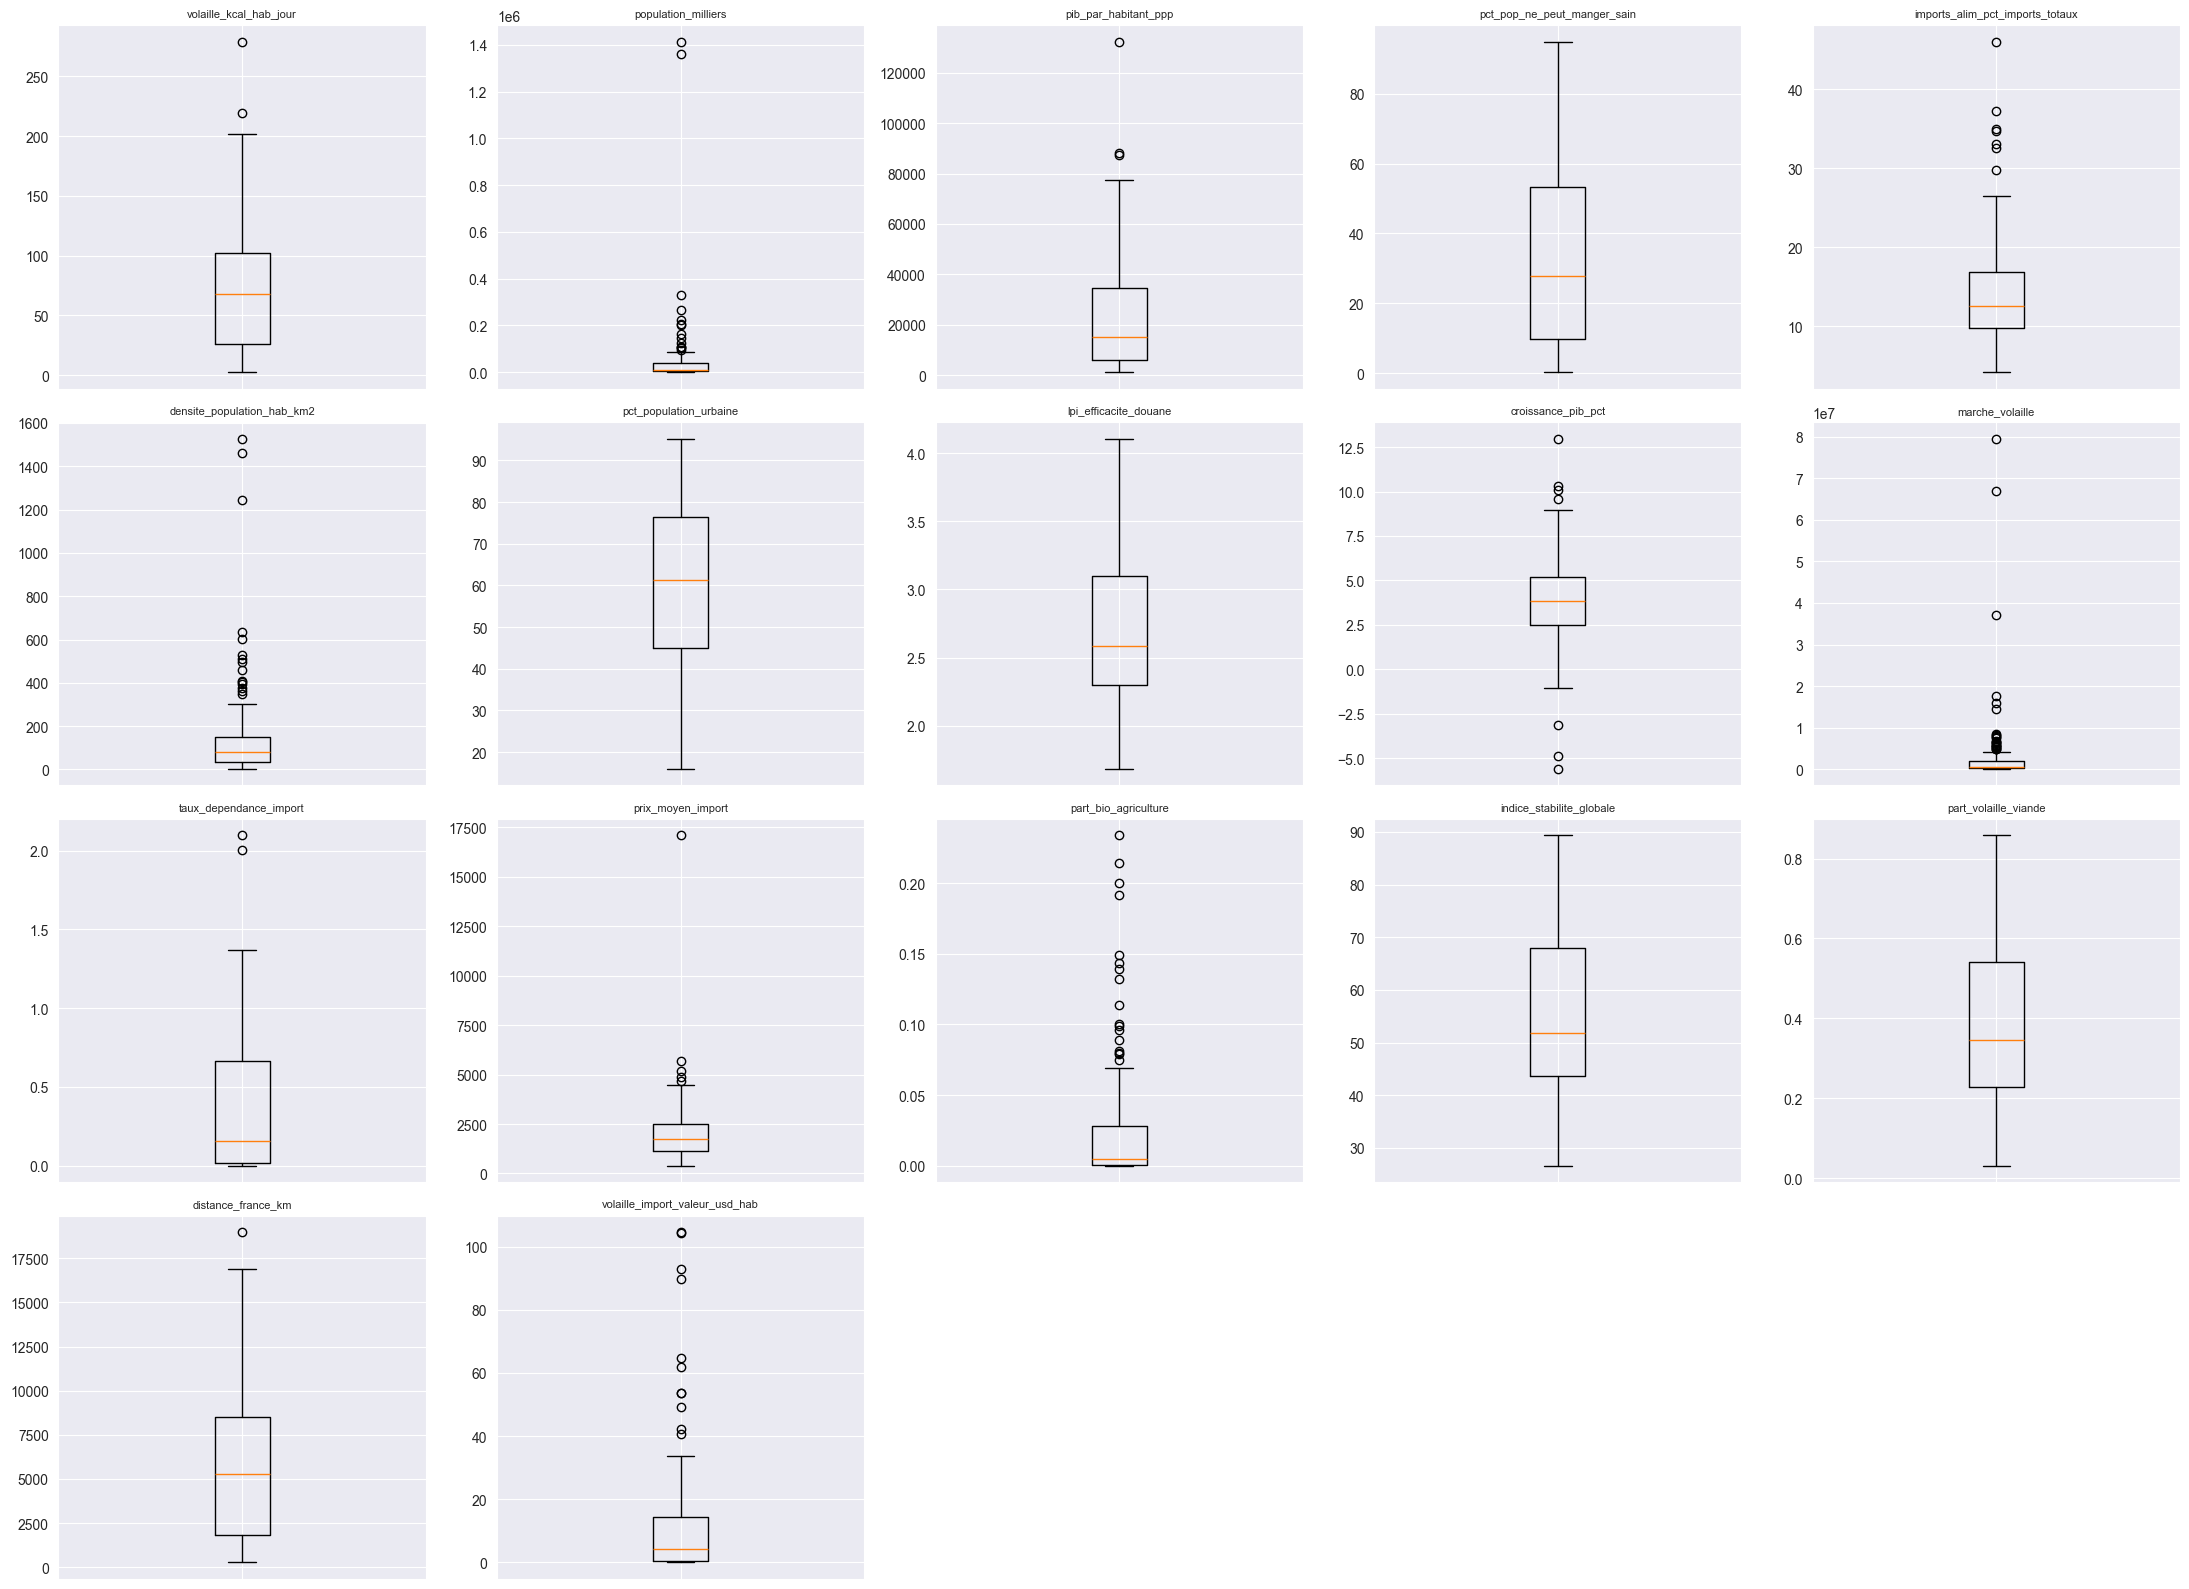

In [14]:
# Boxplots
fig, axes = plt.subplots(4, 5, figsize=(22, 16))
for ax, v in zip(axes.flat, VARS):
    ax.boxplot(df[v].dropna(), vert=True)
    ax.set_title(v, fontsize=8)
    ax.tick_params(axis="x", labelbottom=False)
for ax in axes.flat[len(VARS):]:
    ax.set_visible(False)
plt.tight_layout(); plt.show()

## 8. Corrélations et justification finale des variables

La matrice de corrélation vérifie qu'aucune paire ne fait doublon (redondance qui biaiserait l'ACP).
Les choix de conception limitent d'emblée les redondances : **une** variable de gouvernance (moyenne
des 5 scores WGI, très corrélés), **un** volet du LPI (douane), des grandeurs **par habitant** plutôt
qu'en total (le PIB total et le RNB, corrélés ~1 avec population×PIB/hab, ne sont pas retenus).

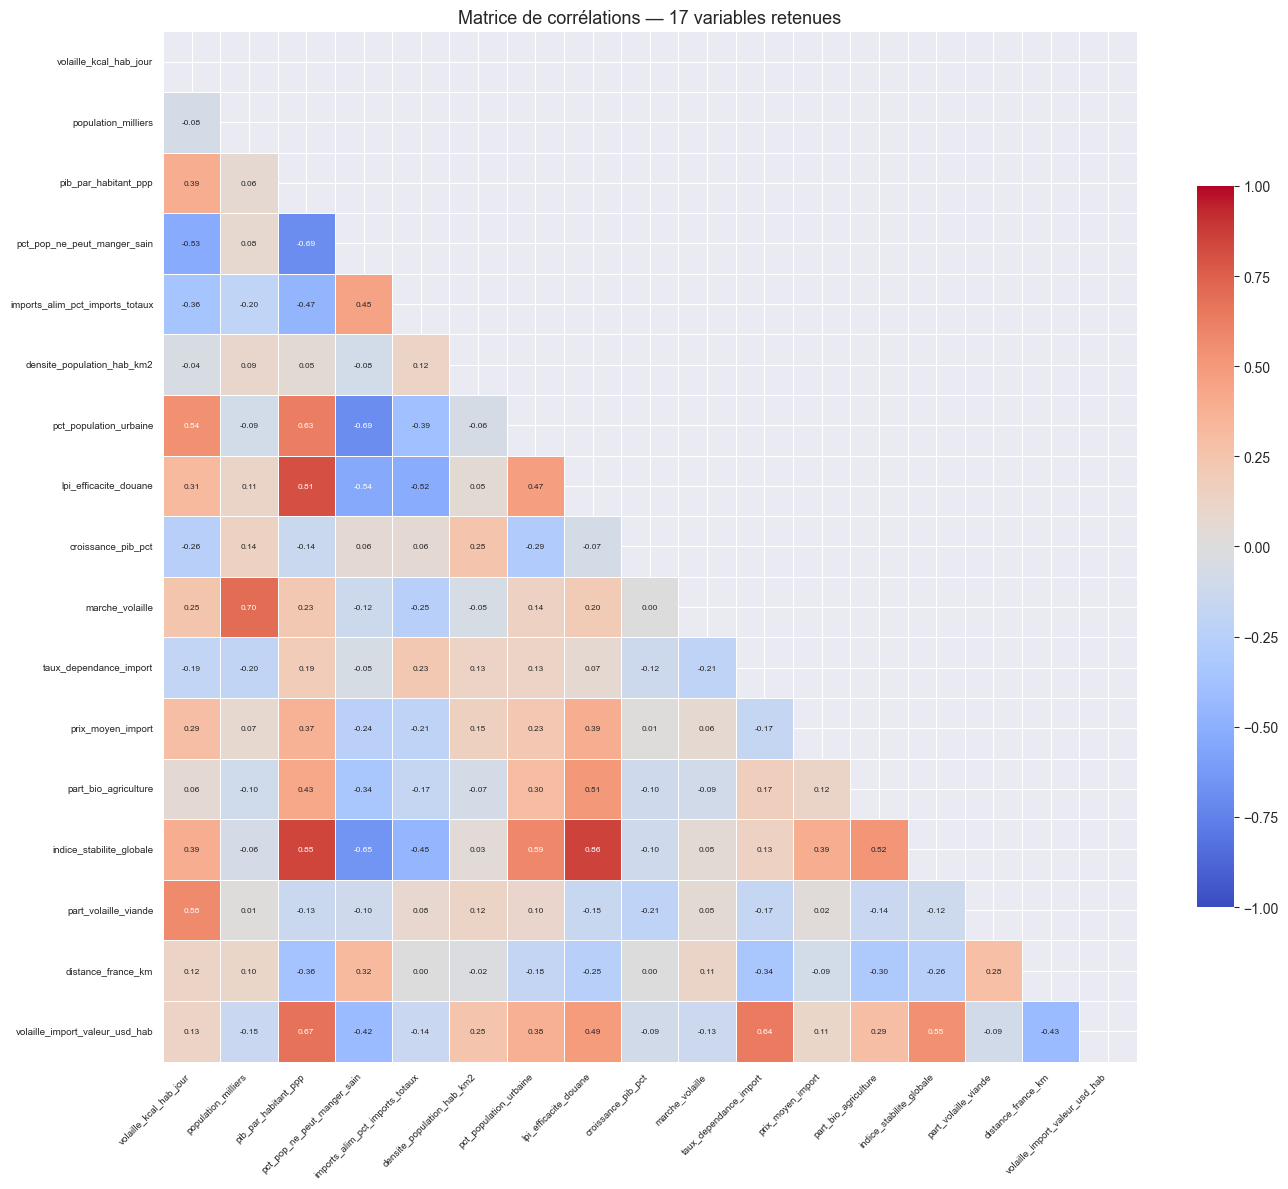

Paires les plus corrélées (|r|) :
  indice_stabilite_globale  ↔  lpi_efficacite_douane : 0.86
  indice_stabilite_globale  ↔  pib_par_habitant_ppp : 0.85
  lpi_efficacite_douane  ↔  pib_par_habitant_ppp : 0.81
  marche_volaille  ↔  population_milliers : 0.70
  pct_pop_ne_peut_manger_sain  ↔  pib_par_habitant_ppp : 0.69
  pct_population_urbaine  ↔  pct_pop_ne_peut_manger_sain : 0.69
  volaille_import_valeur_usd_hab  ↔  pib_par_habitant_ppp : 0.67
  indice_stabilite_globale  ↔  pct_pop_ne_peut_manger_sain : 0.65


In [15]:
corr = df[VARS].corr()
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 6}, linewidths=.5,
            cbar_kws={"shrink": .7})
plt.title("Matrice de corrélations — 17 variables retenues", fontsize=13)
plt.xticks(rotation=45, ha="right", fontsize=7); plt.yticks(fontsize=7)
plt.tight_layout(); plt.show()

# Paires les plus corrélées (contrôle de redondance)
pairs = (corr.where(~mask).abs().stack().sort_values(ascending=False).head(8))
print("Paires les plus corrélées (|r|) :")
for (a, b), r in pairs.items():
    print(f"  {a}  ↔  {b} : {r:.2f}")

### Justification des 17 variables (lecture PESTEL)

| Variable | Axe PESTEL | Question business |
|---|---|---|
| pib_par_habitant_ppp | Économique | Le pays peut-il payer un produit premium ? |
| volaille_import_valeur_usd_hab | Économique | Habitude d'importer de la volaille (en valeur/hab) ? |
| imports_alim_pct_imports_totaux | Économique | Dépendance alimentaire globale ? |
| marche_volaille | Économique/Social | Taille totale du marché volaille ? |
| taux_dependance_import | Économique | Besoin d'importer de la volaille (imports/dispo intérieure) ? |
| prix_moyen_import | Économique | Positionnement premium du marché ($/t) ? |
| croissance_pib_pct | Économique | Marché en expansion ? |
| volaille_kcal_hab_jour | Social | Consommation de volaille par habitant ? |
| population_milliers | Social | Nombre de clients potentiels ? |
| pct_pop_ne_peut_manger_sain | Social | Accès économique à une alimentation saine ? |
| pct_population_urbaine | Social | Canaux de distribution (urbains) ? |
| densite_population_hab_km2 | Social | Efficacité logistique de la distribution ? |
| part_volaille_viande | Social | Place culturelle de la volaille dans la viande ? |
| indice_stabilite_globale | Politique/Légal | Environnement d'affaires sûr (gouvernance) ? |
| lpi_efficacite_douane | Technologique | Facilité de passage en douane (produit périssable) ? |
| distance_france_km | Technologique | Coût logistique / fraîcheur ? |
| part_bio_agriculture | Environnemental | Maturité du marché bio ? |

## 9. Standardisation (Z-score) et export

Les variables ont des échelles très différentes (population en millions, part bio ~0,2, scores 0–100).
On applique une standardisation **Z-score** (moyenne 0, écart-type 1) pour que chaque variable pèse
autant dans l'ACP. On exporte le jeu **brut** (interprétation) et le jeu **standardisé** (Notebook 2).

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = df[["pays", "code_iso3"]].copy()
df_scaled[VARS] = scaler.fit_transform(df[VARS])

print("Vérification standardisation (moyenne ≈ 0, écart-type ≈ 1) :")
print(df_scaled[VARS].describe().loc[["mean", "std"]].round(3).T.head().to_string())

df.to_csv(DATA_DIR / "dataset_final.csv", index=False, encoding="utf-8-sig")
df_scaled.to_csv(DATA_DIR / "dataset_final_scaled.csv", index=False, encoding="utf-8-sig")
print(f"\n✅ Exports écrits dans {DATA_DIR} :")
print("   - dataset_final.csv         (brut, pour interprétation)")
print("   - dataset_final_scaled.csv  (standardisé, pour le Notebook 2)")

Vérification standardisation (moyenne ≈ 0, écart-type ≈ 1) :
                                 mean    std
volaille_kcal_hab_jour            0.0  1.004
population_milliers              -0.0  1.004
pib_par_habitant_ppp             -0.0  1.004
pct_pop_ne_peut_manger_sain       0.0  1.004
imports_alim_pct_imports_totaux   0.0  1.004

✅ Exports écrits dans ..\Raw_data\UtilisésNotebook :
   - dataset_final.csv         (brut, pour interprétation)
   - dataset_final_scaled.csv  (standardisé, pour le Notebook 2)
